# **Deteksi Aksara Jawa | K-Nearest Neighbous**

Model terjemah dataset numerik aksara jawa menggunakan algoritma K-Nearest Neighbous.

**Dikerjakan oleh**:
- Akhyar Bima 
- Silmy Muthi'ah Aulya

**SMK Negeri 2 Singosari**

## 1. Data Preparation

### 1.2 Import Library

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Read Dataset 

In [51]:
# Baca file excel 
xls = pd.ExcelFile('Data - Non Label.xlsx')
xls.sheet_names

['Training', 'Testing']

In [52]:
df_train = pd.read_excel('Data - Non Label.xlsx', sheet_name='Training')
df_test = pd.read_excel('Data - Non Label.xlsx', sheet_name='Testing')

In [ ]:
# Impor file csv
try:
    df.to_csv('data_train.csv', index=False)
    df_test.to_csv('data_test.csv', index=False)
    print('Data berhasil terbaca.')

except ValueError:
    print('Dataset gagal terbaca.')

NameError: name 'df' is not defined

In [ ]:
# 5 baris teratas
print('5 baris teratas: ')
df.head()

5 baris teratas: 


NameError: name 'df' is not defined

In [ ]:
print('10 baris acak:')
df.sample(10)

10 baris acak:


,No,HURUF,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
222,9,WA,73,40,153,249,151,139,181,176,120,127,6,272,136,176,217,78
407,19,THA,76,22,0,122,73,56,0,60,82,60,2,61,48,97,109,23
245,11,PA,35,103,0,210,72,90,65,117,62,167,204,92,81,0,2,0
170,7,TA,328,352,374,261,187,439,208,198,185,302,306,197,191,474,107,101
217,9,WA,183,86,138,434,186,192,0,366,227,148,27,316,269,270,250,176
34,2,NA,131,48,85,116,80,129,208,83,77,90,82,84,70,8,0,24
335,15,NYA,117,80,147,142,112,0,65,114,87,0,55,110,86,66,47,100
208,9,WA,250,100,230,178,135,126,149,117,144,137,136,102,140,175,166,120
271,12,DHA,124,21,170,219,116,101,0,165,100,104,57,190,96,86,165,67
367,17,GA,394,275,295,234,186,141,333,182,214,69,228,165,222,19,134,96


In [ ]:
# Dimensi data
print('Dimensi data:\n')
print('Jumlah baris:', df.shape[0])
print('Jumlah kolom:', df.shape[1])

Dimensi data:

Jumlah baris: 449
Jumlah kolom: 18


In [ ]:
# Ringkasan informasi 
print('Ringkasan Informasi:\n')
df.info()

Ringkasan Informasi:

<class 'pandas.core.frame.DataFrame'>
Index: 449 entries, 0 to 449
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   No      449 non-null    int64 
 1   HURUF   449 non-null    object
 2   Z1      449 non-null    int64 
 3   Z2      449 non-null    int64 
 4   Z3      449 non-null    int64 
 5   Z4      449 non-null    int64 
 6   Z5      449 non-null    int64 
 7   Z6      449 non-null    int64 
 8   Z7      449 non-null    int64 
 9   Z8      449 non-null    int64 
 10  Z9      449 non-null    int64 
 11  Z10     449 non-null    int64 
 12  Z11     449 non-null    int64 
 13  Z12     449 non-null    int64 
 14  Z13     449 non-null    int64 
 15  Z14     449 non-null    int64 
 16  Z15     449 non-null    int64 
 17  Z16     449 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 66.6+ KB


In [ ]:
# Ringkasan statistik
print('Ringkasan statistik:')
df.describe()

Ringkasan statistik:


,No,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
count,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000
mean,10.151448,167.469933,117.345212,160.086860,202.434298,122.984410,127.282851,107.207127,150.650334,119.592428,138.846325,129.779510,146.425390,94.452116,152.665924,121.082405,99.717149
std,5.859535,89.977500,93.599254,102.686672,86.340459,72.912143,77.754752,82.980201,67.423238,73.014101,88.410346,98.514765,64.692158,62.382805,91.511439,86.445146,56.655228
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,100.000000,49.000000,81.000000,140.000000,71.000000,73.000000,47.000000,104.000000,73.000000,79.000000,61.000000,95.000000,54.000000,88.000000,62.000000,59.000000
50%,9.000000,151.000000,91.000000,149.000000,189.000000,110.000000,117.000000,102.000000,142.000000,105.000000,123.000000,114.000000,139.000000,81.000000,138.000000,110.000000,93.000000
75%,15.000000,232.000000,166.000000,225.000000,252.000000,163.000000,167.000000,156.000000,194.000000,159.000000,181.000000,184.000000,194.000000,123.000000,206.000000,177.000000,131.000000
max,20.000000,528.000000,504.000000,457.000000,599.000000,427.000000,537.000000,403.000000,366.000000,423.000000,463.000000,523.000000,370.000000,342.000000,474.000000,416.000000,310.000000


In [ ]:
# Penyebaran data label
print('Penyebaran data label:')
df['No'].value_counts()

Penyebaran data label:


No
6     46
2     24
1     23
3     23
4     23
5     23
7     23
8     23
9     22
11    22
12    22
13    22
14    22
15    22
16    22
17    22
19    22
20    22
18    21
Name: count, dtype: int64

In [ ]:
# Cek nilai unik
print('Nilai unik label:')
df['HURUF'].unique()

Nilai unik label:


array(['HA', 'NA', 'CA', 'RA', 'KA', 'DA', 'LA', 'TA', 'SA', 'WA', 'PA',
       'DHA', 'JA', 'YA', 'NYA', 'MA', 'GA', 'BA', 'THA', 'NGA'],
      dtype=object)

Tidak ada huruf 'Na'.

In [ ]:
print('Nilai unik label:')
df['No'].unique()

Nilai unik label:


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20])

In [ ]:
# 10 baris acak dari 2 kolom
print("10 baris acak fitur 'No' dan 'HURUF':")
df[['No', 'HURUF']].head()

10 baris acak fitur 'No' dan 'HURUF':


,No,HURUF
0,1,HA
1,1,HA
2,1,HA
3,1,HA
4,1,HA


### 1.3 Data Cleaning

#### 1.3.1 Missing Value

In [ ]:
# Cek missing value 
print('Total missing value:', df.isnull().sum().sum())

Total missing value: 0


In [ ]:
# Cek nilai kososng per kolom
print('Jumlah nilai kosong per kolom:\n')
df.isnull().sum()

Jumlah nilai kosong per kolom:



No       0
HURUF    0
Z1       0
Z2       0
Z3       0
Z4       0
Z5       0
Z6       0
Z7       0
Z8       0
Z9       0
Z10      0
Z11      0
Z12      0
Z13      0
Z14      0
Z15      0
Z16      0
dtype: int64

In [ ]:
# Cek baris missing value 
print('Cek baris yang memiliki missing value:')
df[df.isnull().any(axis=1)]

Cek baris yang memiliki missing value:


,No,HURUF,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16


In [ ]:
# Mengatasi missing value
"""
Kami mengisi nilai kosng dengan huruf 'Na'
""" 
df['HURUF'] = df['HURUF'].fillna('NA')
df['HURUF'].unique()

array(['HA', 'NA', 'CA', 'RA', 'KA', 'DA', 'LA', 'TA', 'SA', 'WA', 'PA',
       'DHA', 'JA', 'YA', 'NYA', 'MA', 'GA', 'BA', 'THA', 'NGA'],
      dtype=object)

In [ ]:
# Cek total nilai kosong
print('Total nilai kosong setelah ditangani:', df.isnull().sum().sum())

Total nilai kosong setelah ditangani: 0


#### 1.3.2 Nilai Duplikat

In [ ]:
# Cek nilai duplikat 
print('Total nilai duplikat:', df.duplicated().sum())

Total nilai duplikat: 0


In [ ]:
# Menampilkan nili duplikat
print('Baris duplikat:')
df[df.duplicated(keep=False)]

Baris duplikat:


,No,HURUF,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16


In [ ]:
# Mengangain nilai duplikat
df.drop_duplicates(inplace=True)

print('Total nilai duplikat setelah ditangani:', df.duplicated().sum())

Total nilai duplikat setelah ditangani: 0


## 2. Exploratory Data Analysis (EDA)

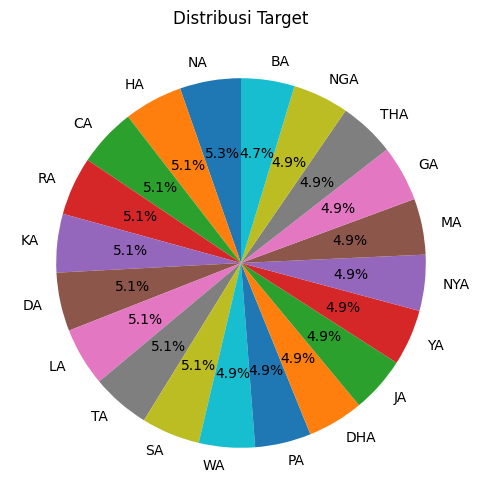

In [ ]:
# Penyebaran target dengan grafik pie
plt.figure(figsize=(6,6))
df['HURUF'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)
plt.ylabel('')
plt.title('Distribusi Target')
plt.show()


Dari grafik pie diatas, terlihat penyebaran data balance, dengan huruf terbanyak adalah huruf 'NA'.

## 3. Model

In [ ]:
df_test.head()

,No. Urut,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11,Z12,Z13,Z14,Z15,Z16
0,1,192,200,68,280,148,188,343,253,166,187,156,313,148,76,16,146
1,2,142,87,0,234,150,297,0,225,96,278,0,240,96,88,168,114
2,3,149,160,67,224,135,155,159,157,139,136,159,150,136,158,248,179
3,4,177,100,167,170,91,104,92,95,101,210,97,108,90,240,200,98
4,5,273,62,341,344,196,39,143,252,224,0,120,234,159,95,118,47


In [ ]:
X = df_train.drop(['No', 'HURUF'], axis=1).values
y =  df_train['No'].values

y_test = df_test[]

In [ ]:
X_max = X.max(axis=0)
X_min = X.min(axis=0)

X_train_scaled = (X - X_min) / (X_max - X_min)

In [ ]:
import pandas as pd

# 1. Tentukan target dan rasio
target = 'No'
val_size = 0.15
test_size = 0.8

# 2. Pisahkan data secara manual per kategori
train_list, val_list, test_list = [], [], []

for label, group in df_train.groupby(target):
    # Acak urutan data dalam grup
    group = group.sample(frac=1, random_state=42)
    
    # Hitung jumlah baris untuk masing-masing bagian
    n_val = int(len(group) * val_size)
    n_test = int(len(group) * test_size)
    
    # Potong-potong datanya
    val_part = group.iloc[:n_val]
    test_part = group.iloc[n_val : n_val + n_test]
    train_part = group.iloc[n_val + n_test:]
    
    # Masukkan ke list
    val_list.append(val_part)
    test_list.append(test_part)
    train_list.append(train_part)

# 3. Gabungkan kembali semua potongan
train_df = pd.concat(train_list).sample(frac=1)
val_df = pd.concat(val_list).sample(frac=1)
test_df = pd.concat(test_list).sample(frac=1)

# Cek hasilnya
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 40, Val: 60, Test: 350


In [ ]:
x = X[0]

In [ ]:
def knn(X, y, x_new, k=5):
    # X: data fitur training (array)
    # y: label training (array)
    # x_new: SATU baris data yang mau diprediksi (vector)
    
    # Menghitung jarak Euclidean antara x_new dan SETIAP baris di X
    distance = np.linalg.norm(X - x_new, axis=1)
    
    # Mengambil indeks k tetangga terdekat
    nearest = np.argsort(distance)[:k]
    
    # Mengambil label dari tetangga terdekat
    nearest_labels = y[nearest]
    
    # Voting terbanyak (mengambil label yang paling sering muncul)
    # Jika klasifikasi:
    prediction = pd.Series(nearest_labels).mode()[0]
    return prediction

In [ ]:
# 1. Siapkan data (pastikan hanya kolom numerik untuk X)
X_train = train_df.drop(columns=['No', 'HURUF']).values
y_train = train_df['No'].values
X_val = val_df.drop(columns=['No', 'HURUF']).values
y_val = val_df['No'].values

k_candidate = [3,5,7,9,11]
history = []
best_k = None
best_acc = -1

for k in k_candidate:
    # Prediksi setiap baris di data validasi
    # x adalah satu baris fitur dari X_val
    predictions = [knn(X_train, y_train, x, k=k) for x in X_val]
    
    # Hitung akurasi
    predictions = np.array(predictions)
    accuracy = np.mean(predictions == y_val)
    
    print(f'k {k} akurasi {accuracy}')

    if accuracy > best_acc:
        best_acc = accuracy
        best_k = k
        
print(f'best k: {best_k}')

k 3 akurasi 0.18333333333333332
k 5 akurasi 0.18333333333333332
k 7 akurasi 0.2
k 9 akurasi 0.23333333333333334
k 11 akurasi 0.23333333333333334
best k: 9


In [ ]:
# k_candidate = range(1,11)
# best_k = None
# best_accuracy = -1
# history = []

# for k in k_candidate:
#     knn_1 = [knn(train_df, test_df, val_df, k=k) for x in train_df]

#     accuracy = np.mean(knn_1 == val_df)
#     history.append({'k:': k, 'accuracy:': accuracy})
#     print(f'K: {k} akurasi: {accuracy}')

#     if accuracy > best_accuracy:
#         best_accuracy = accuracy
#         best_k = k

# print(f'best k: {best_k}')

TypeError: loop of ufunc does not support argument 0 of type float which has no callable sqrt method

## 4. Evaluasi